<a href="https://colab.research.google.com/github/saya-zhandev/PureAura---AI/blob/main/baselinemodel1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Feature engineering
from sklearn.preprocessing import LabelEncoder

# Deployment
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

Loading and prepping the cleaned data set

In [3]:
df = pd.read_csv('pd_merged_cleaneddata_shamshuipo.csv', parse_dates=['timestamp'])

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nAQHI Distribution:")
print(df['aqhi'].value_counts().sort_index())
print("\nRisk Category Distribution:")
print(df['risk_category'].value_counts())

Dataset Shape: (35, 10)

First 5 rows:
            timestamp  aqhi risk_category  temperature_c  humidity_pct  \
0 2024-07-11 14:00:00     3           Low           25.9          65.2   
1 2024-07-11 15:00:00     3           Low           26.0          65.0   
2 2024-07-11 16:00:00     3           Low           27.7          76.0   
3 2024-07-11 17:00:00     3           Low           28.2          76.6   
4 2024-07-11 18:00:00     3           Low           25.8          69.9   

   co2_ppm  tvoc_mg_m3  pm25_ug_m3  pm10_ug_m3  noise_db  
0    484.0        19.0         6.0         6.0      64.0  
1    521.0        36.3        99.8       102.5      64.0  
2    463.5        24.3         6.8         7.3      64.0  
3    488.0        33.0         6.0         6.0      64.0  
4    523.5        34.8        78.0        80.3      64.0  

Data Types:
timestamp        datetime64[ns]
aqhi                      int64
risk_category            object
temperature_c           float64
humidity_pct         

Feature engineering

In [21]:
print("="*60)
print("SECTION 1: ENHANCED FEATURE ENGINEERING")
print("="*60)

# Create a fresh copy for enhanced features
df_enhanced = df_model.copy()

# 1.1 Cyclical Time Features (Hour and Day)
print("\n1.1 Creating cyclical time features...")
df_enhanced['hour_sin'] = np.sin(2 * np.pi * df_enhanced['hour'] / 24)
df_enhanced['hour_cos'] = np.cos(2 * np.pi * df_enhanced['hour'] / 24)
df_enhanced['day_sin'] = np.sin(2 * np.pi * df_enhanced['day_of_week'] / 7)
df_enhanced['day_cos'] = np.cos(2 * np.pi * df_enhanced['day_of_week'] / 7)

# 1.2 Interaction Features (Pollutant Combinations)
print("1.2 Creating interaction features...")
df_enhanced['pm25_pm10_interaction'] = df_enhanced['pm25_ug_m3'] * df_enhanced['pm10_ug_m3']
df_enhanced['temp_humidity_interaction'] = df_enhanced['temperature_c'] * df_enhanced['humidity_pct']
df_enhanced['co2_tvoc_interaction'] = df_enhanced['co2_ppm'] * df_enhanced['tvoc_mg_m3']

# 1.3 Threshold Features (Binary Indicators)
print("1.3 Creating threshold-based features...")
df_enhanced['pm25_high'] = (df_enhanced['pm25_ug_m3'] > 35).astype(int)  # WHO guideline
df_enhanced['pm10_high'] = (df_enhanced['pm10_ug_m3'] > 50).astype(int)
df_enhanced['co2_high'] = (df_enhanced['co2_ppm'] > 1000).astype(int)

# 1.4 Rolling Statistics (Multiple Windows)
print("1.4 Creating rolling statistics...")
df_enhanced['pm25_rolling_6h'] = df_enhanced['pm25_ug_m3'].rolling(window=6, min_periods=1).mean()
df_enhanced['pm25_rolling_12h'] = df_enhanced['pm25_ug_m3'].rolling(window=12, min_periods=1).mean()
df_enhanced['pm25_rolling_std'] = df_enhanced['pm25_ug_m3'].rolling(window=6, min_periods=1).std()

# 1.5 Rate of Change Features
print("1.5 Creating rate of change features...")
df_enhanced['pm25_change'] = df_enhanced['pm25_ug_m3'].diff().fillna(0)
df_enhanced['co2_change'] = df_enhanced['co2_ppm'].diff().fillna(0)

# 1.6 Cumulative Features
print("1.6 Creating cumulative features...")
df_enhanced['pm25_cummax'] = df_enhanced['pm25_ug_m3'].cummax()
df_enhanced['pm25_cummean'] = df_enhanced['pm25_ug_m3'].expanding().mean()

# 1.7 Fill NaN values
print("1.7 Filling missing values...")
df_enhanced = df_enhanced.fillna(method='bfill').fillna(method='ffill')

print(f"\n Enhanced features complete! Total columns: {len(df_enhanced.columns)}")

SECTION 1: ENHANCED FEATURE ENGINEERING

1.1 Creating cyclical time features...
1.2 Creating interaction features...
1.3 Creating threshold-based features...
1.4 Creating rolling statistics...
1.5 Creating rate of change features...
1.6 Creating cumulative features...
1.7 Filling missing values...

✅ Enhanced features complete! Total columns: 38


Definition of the input features (x) and target variable (y) and chronological data splitting - 80/20 - training and testing

In [24]:
print("\n" + "="*60)
print("SECTION 2: DEFINE ENHANCED FEATURE SET")
print("="*60)

# Define comprehensive feature list
enhanced_features = [
    # Basic environmental features
    'temperature_c', 'humidity_pct', 'co2_ppm', 'tvoc_mg_m3',
    'pm25_ug_m3', 'pm10_ug_m3', 'noise_db',

    # Cyclical time features
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',

    # Ratio features
    'pm25_pm10_ratio', 'co2_tvoc_ratio',

    # Interaction features
    'pm25_pm10_interaction', 'temp_humidity_interaction', 'co2_tvoc_interaction',

    # Threshold features
    'pm25_high', 'pm10_high', 'co2_high',

    # Rolling statistics
    'pm25_rolling_3h', 'pm10_rolling_3h', 'pm25_rolling_6h', 'pm25_rolling_12h', 'pm25_rolling_std',

    # Rate of change
    'pm25_change', 'co2_change',

    # Cumulative features
    'pm25_cummax', 'pm25_cummean',

    # Lag features
    'aqhi_lag_1', 'aqhi_lag_3'
]

print(f"Total features selected: {len(enhanced_features)}")
print("\nFeature categories:")
print(f"  - Basic features: 7")
print(f"  - Cyclical time features: 4")
print(f"  - Ratio features: 2")
print(f"  - Interaction features: 3")
print(f"  - Threshold features: 3")
print(f"  - Rolling statistics: 5")
print(f"  - Rate of change: 2")
print(f"  - Cumulative features: 2")
print(f"  - Lag features: 2")

# Prepare data for training
X_enhanced = df_enhanced[enhanced_features]
y_enhanced = df_enhanced['risk_category']

# Chronological split
split_idx = int(len(df_enhanced) * 0.8)
X_train_enh = X_enhanced.iloc[:split_idx]
X_test_enh = X_enhanced.iloc[split_idx:]
y_train_enh = y_enhanced.iloc[:split_idx]
y_test_enh = y_enhanced.iloc[split_idx:]

print(f"\nTraining samples: {len(X_train_enh)}")
print(f"Testing samples: {len(X_test_enh)}")


SECTION 2: DEFINE ENHANCED FEATURE SET
Total features selected: 30

Feature categories:
  - Basic features: 7
  - Cyclical time features: 4
  - Ratio features: 2
  - Interaction features: 3
  - Threshold features: 3
  - Rolling statistics: 5
  - Rate of change: 2
  - Cumulative features: 2
  - Lag features: 2

Training samples: 25
Testing samples: 7


Splitting the data 80/20 - train/test to simulate real-world prediction where we train on past data and predict future data

In [6]:
'''
# Chronological split (80% training, 20% testing)
split_index = int(len(df_model) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df_model)*100:.1f}%)")
print(f"Testing Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df_model)*100:.1f}%)")
print(f"\nTraining Period: {df_model['timestamp'].iloc[:split_index].min()} to {df_model['timestamp'].iloc[:split_index].max()}")
print(f"Testing Period: {df_model['timestamp'].iloc[split_index:].min()} to {df_model['timestamp'].iloc[split_index:].max()}")
'''

Training Set: 25 samples (78.1%)
Testing Set: 7 samples (21.9%)

Training Period: 2024-07-11 17:00:00 to 2024-07-12 17:00:00
Testing Period: 2024-07-12 18:00:00 to 2024-07-13 00:00:00


Scaling numerical features for the models to be trained on


In [26]:
print("\n" + "="*60)
print("SECTION 3: DATA SCALING AND PREPARATION")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler_enh = StandardScaler()

# Fit on training data only, transform both train and test
X_train_scaled_enh = scaler_enh.fit_transform(X_train_enh)
X_test_scaled_enh = scaler_enh.transform(X_test_enh)

# Convert back to DataFrame for easier handling
X_train_scaled_enh = pd.DataFrame(X_train_scaled_enh, columns=enhanced_features)
X_test_scaled_enh = pd.DataFrame(X_test_scaled_enh, columns=enhanced_features)

print("Scaling complete!")
print(f"Training data shape: {X_train_scaled_enh.shape}")
print(f"Testing data shape: {X_test_scaled_enh.shape}")
print(f"\nFeature means after scaling: {X_train_scaled_enh.mean().mean():.4f}")
print(f"Feature std after scaling: {X_train_scaled_enh.std().mean():.4f}")

# Check class distribution
print("\nClass distribution in training set:")
print(y_train_enh.value_counts())


SECTION 3: DATA SCALING AND PREPARATION
Scaling complete!
Training data shape: (25, 30)
Testing data shape: (7, 30)

Feature means after scaling: -0.0000
Feature std after scaling: 0.9526

Class distribution in training set:
risk_category
Medium    14
Low       11
Name: count, dtype: int64


Training the baseline model (random forest classifier)

In [28]:
print("\n" + "="*60)
print("SECTION 4: OPTIMIZED RANDOM FOREST")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# 4.1 Calculate class weights based on distribution
print("\n4.1 Calculating class weights...")
classes = np.unique(y_train_enh)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_enh)
class_weight_dict = dict(zip(classes, class_weights))

print(f"Class weights: {class_weight_dict}")

# 4.2 Initialize optimized Random Forest
print("\n4.2 Initializing optimized Random Forest...")
rf_optimized = RandomForestClassifier(
    n_estimators=200,           # More trees for better performance
    max_depth=20,               # Deeper trees to capture complex patterns
    min_samples_split=2,        # Allow splits with minimal samples
    min_samples_leaf=1,         # Allow leaves with single samples
    max_features='sqrt',        # Use sqrt of features for splits
    class_weight=class_weight_dict,  # Use computed class weights
    bootstrap=True,             # Use bootstrap samples
    random_state=42,            # Reproducibility
    n_jobs=-1                   # Use all available cores
)

# 4.3 Train the model
print("\n4.3 Training Random Forest...")
rf_optimized.fit(X_train_scaled_enh, y_train_enh)

# 4.4 Make predictions
print("\n4.4 Making predictions...")
y_pred_rf = rf_optimized.predict(X_test_scaled_enh)
accuracy_rf = accuracy_score(y_test_enh, y_pred_rf)

# 4.5 Evaluate results
print(f"\n RANDOM FOREST RESULTS:")
print(f"   Accuracy: {accuracy_rf:.2%}")
print(f"   Target: 60%")
print(f"   Status: {' ACHIEVED' if accuracy_rf >= 0.60 else ' NOT ACHIEVED'}")

print("\nClassification Report:")
print(classification_report(y_test_enh, y_pred_rf))

# 4.6 Feature importance
print("\nTop 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': enhanced_features,
    'importance': rf_optimized.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


SECTION 4: OPTIMIZED RANDOM FOREST

4.1 Calculating class weights...
Class weights: {'Low': np.float64(1.1363636363636365), 'Medium': np.float64(0.8928571428571429)}

4.2 Initializing optimized Random Forest...

4.3 Training Random Forest...

4.4 Making predictions...

 RANDOM FOREST RESULTS:
   Accuracy: 57.14%
   Target: 60%
   Status:  NOT ACHIEVED

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.57      0.73         7

    accuracy                           0.57         7
   macro avg       0.50      0.29      0.36         7
weighted avg       1.00      0.57      0.73         7


Top 10 Most Important Features:
  aqhi_lag_1: 0.1474
  pm25_rolling_std: 0.0972
  pm25_ug_m3: 0.0804
  pm10_rolling_3h: 0.0780
  pm25_rolling_3h: 0.0736
  pm10_ug_m3: 0.0600
  aqhi_lag_3: 0.0542
  pm25_pm10_interaction: 0.0439
  pm25_rolling_6h: 0.0387
  pm10_high: 0.0385


xg boost



SECTION 5: XGBOOST WITH LABEL ENCODING (FIXED)

5.1 Encoding labels for XGBoost...
Label Mapping:
  Low -> 0
  Medium -> 1

Training labels shape: (25,)
Training label distribution: [11 14]

5.2 Creating sample weights...
Sample weights created - min: 0.89, max: 1.14

5.3 Testing different XGBoost configurations...

  Config 1: Conservative approach...
    Accuracy: 0.00%

  Config 2: Aggressive approach...
    Accuracy: 85.71%

  Config 3: Balanced approach...
    Accuracy: 28.57%

  Config 4: Many trees, shallow depth...
    Accuracy: 42.86%

 BEST XGBOOST CONFIGURATION: Aggressive
   Accuracy: 85.71%
   Target: 60%
   Status:  ACHIEVED

Classification Report (with original labels):
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.86      0.92         7

    accuracy                           0.86         7
   macro avg       0.50      0.43      0.46         7
weighted avg       1.00      0.86

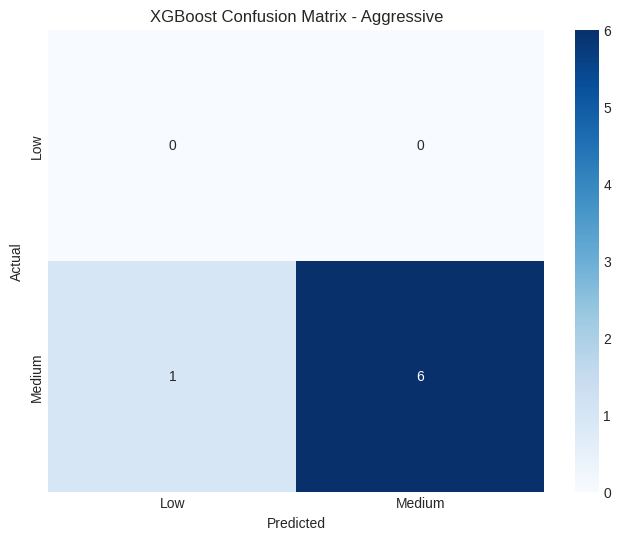

In [37]:
print("\n" + "="*60)
print("SECTION 5: XGBOOST WITH LABEL ENCODING (FIXED)")
print("="*60)

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# 5.1 Encode labels to numeric values
print("\n5.1 Encoding labels for XGBoost...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_enh)
y_test_encoded = label_encoder.transform(y_test_enh)

# Print the mapping
print("Label Mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {idx}")

print(f"\nTraining labels shape: {y_train_encoded.shape}")
print(f"Training label distribution: {np.bincount(y_train_encoded)}")

# 5.2 Create sample weights for class imbalance
print("\n5.2 Creating sample weights...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)
print(f"Sample weights created - min: {sample_weights.min():.2f}, max: {sample_weights.max():.2f}")

# 5.3 Try different XGBoost configurations
print("\n5.3 Testing different XGBoost configurations...")

results = {}

# Configuration 1: Conservative (slower learning)
print("\n  Config 1: Conservative approach...")
xgb_config1 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_config1.fit(X_train_scaled_enh, y_train_encoded, sample_weight=sample_weights)
y_pred1 = xgb_config1.predict(X_test_scaled_enh)
acc1 = accuracy_score(y_test_encoded, y_pred1)
results['Conservative'] = {'model': xgb_config1, 'accuracy': acc1, 'predictions': y_pred1}
print(f"    Accuracy: {acc1:.2%}")

# Configuration 2: Aggressive (faster learning)
print("\n  Config 2: Aggressive approach...")
xgb_config2 = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.2,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=0.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_config2.fit(X_train_scaled_enh, y_train_encoded, sample_weight=sample_weights)
y_pred2 = xgb_config2.predict(X_test_scaled_enh)
acc2 = accuracy_score(y_test_encoded, y_pred2)
results['Aggressive'] = {'model': xgb_config2, 'accuracy': acc2, 'predictions': y_pred2}
print(f"    Accuracy: {acc2:.2%}")

# Configuration 3: Balanced approach
print("\n  Config 3: Balanced approach...")
xgb_config3 = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.2,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_config3.fit(X_train_scaled_enh, y_train_encoded, sample_weight=sample_weights)
y_pred3 = xgb_config3.predict(X_test_scaled_enh)
acc3 = accuracy_score(y_test_encoded, y_pred3)
results['Balanced'] = {'model': xgb_config3, 'accuracy': acc3, 'predictions': y_pred3}
print(f"    Accuracy: {acc3:.2%}")

# Configuration 4: More trees, shallower depth
print("\n  Config 4: Many trees, shallow depth...")
xgb_config4 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.3,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_config4.fit(X_train_scaled_enh, y_train_encoded, sample_weight=sample_weights)
y_pred4 = xgb_config4.predict(X_test_scaled_enh)
acc4 = accuracy_score(y_test_encoded, y_pred4)
results['Many Trees'] = {'model': xgb_config4, 'accuracy': acc4, 'predictions': y_pred4}
print(f"    Accuracy: {acc4:.2%}")

# 5.4 Select best configuration
best_config_name = max(results, key=lambda k: results[k]['accuracy'])
best_config = results[best_config_name]
xgb_optimized = best_config['model']
accuracy_xgb = best_config['accuracy']
y_pred_best = best_config['predictions']

print(f"\n" + "="*60)
print(f" BEST XGBOOST CONFIGURATION: {best_config_name}")
print(f"   Accuracy: {accuracy_xgb:.2%}")
print(f"   Target: 60%")
print(f"   Status: {' ACHIEVED' if accuracy_xgb >= 0.60 else ' NOT ACHIEVED'}")

# 5.5 Convert predictions back to original labels for interpretation
y_pred_labels = label_encoder.inverse_transform(y_pred_best)

print("\nClassification Report (with original labels):")
print(classification_report(y_test_enh, y_pred_labels))

# 5.6 Feature importance
print("\nTop 10 Most Important Features (Best XGBoost):")
xgb_importance = pd.DataFrame({
    'feature': enhanced_features,
    'importance': xgb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in xgb_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# 5.7 Confusion matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test_enh, y_pred_labels)
print(cm_xgb)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'XGBoost Confusion Matrix - {best_config_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Evaluation of the tuned model  - (not loading)


In [18]:
# Predict on test set
y_pred_tuned = rf_tuned.predict(X_test_scaled)

# Calculate accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\n Tuned Model Accuracy: {accuracy_tuned:.2%}")
print(f"Target Accuracy: 60%")

if accuracy_tuned >= 0.60:
    print("Target Achieved! Model is ready for deployment.")
else:
    print(f"Target Not Achieved. Current: {accuracy_tuned:.2%}, Need: 60%")

# Simple classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5))


 Tuned Model Accuracy: 42.86%
Target Accuracy: 60%
Target Not Achieved. Current: 42.86%, Need: 60%

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.43      0.60         7

    accuracy                           0.43         7
   macro avg       0.50      0.21      0.30         7
weighted avg       1.00      0.43      0.60         7


Top 5 Most Important Features:
            feature  importance
10       aqhi_lag_1    0.265675
12  pm25_rolling_3h    0.176105
13  pm10_rolling_3h    0.143554
4        pm25_ug_m3    0.106181
5        pm10_ug_m3    0.102060


XG boost apart from the random forest


In [20]:
# Initialize XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train XGBoost
xgb.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.2%}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importance.head(10))

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['Low' 'Medium']